Entregable 1
Data Engineering


Importaciones

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd # Librería para la manipulación y el análisis de datos
import numpy as np # Librería para la manipulación de datos y para la ejecución de operaciones matemáticas

Lectura csv

In [3]:
imdb = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/entregable1/bmw_pricing_v3.csv")

In [4]:
imdb

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,asientos_traseros_plegables,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio,fecha_venta
0,NaN,118,140411.0,100.0,2012-02-01,diesel,black,NaN,True,True,False,NaN,True,NaN,True,NaN,11300.0,2018-01-01
1,BMW,M4,13929.0,317.0,NaN,petrol,grey,convertible,True,True,False,NaN,False,True,True,True,69700.0,2018-02-01
2,BMW,320,183297.0,120.0,2012-04-01,diesel,white,NaN,False,False,False,NaN,True,False,True,False,10200.0,2018-02-01
3,BMW,420,128035.0,135.0,NaN,diesel,red,convertible,True,True,False,NaN,True,True,True,NaN,25100.0,2018-02-01
4,BMW,425,97097.0,160.0,NaN,diesel,silver,NaN,True,True,False,False,False,True,True,True,33400.0,2018-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4838,BMW,218 Gran Tourer,39743.0,110.0,NaN,diesel,black,NaN,False,True,False,NaN,False,False,True,False,14600.0,2018-08-01
4839,BMW,218 Active Tourer,49832.0,100.0,2015-06-01,diesel,grey,NaN,False,True,False,NaN,False,False,True,True,17500.0,2018-08-01
4840,BMW,218 Gran Tourer,19633.0,110.0,2015-10-01,diesel,grey,van,False,True,False,NaN,False,False,True,True,17000.0,2018-09-01
4841,BMW,218 Active Tourer,27920.0,110.0,2016-04-01,diesel,brown,van,True,True,False,False,False,False,True,True,22700.0,2018-09-01


Vista inicial

In [5]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4843 entries, 0 to 4842
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marca                        3873 non-null   object 
 1   modelo                       4840 non-null   object 
 2   km                           4841 non-null   float64
 3   potencia                     4842 non-null   float64
 4   fecha_registro               2420 non-null   object 
 5   tipo_gasolina                4838 non-null   object 
 6   color                        4398 non-null   object 
 7   tipo_coche                   3383 non-null   object 
 8   volante_regulable            4839 non-null   object 
 9   aire_acondicionado           4357 non-null   object 
 10  camara_trasera               4841 non-null   object 
 11  asientos_traseros_plegables  1452 non-null   object 
 12  elevalunas_electrico         4841 non-null   object 
 13  bluetooth         

Inicio ejercicio
1. ¿Qué columnas eliminaron inicialmente del dataset y por qué?



Creamos copia del original

In [6]:
imdb2=imdb.copy()

In [17]:
imdb[imdb.duplicated(keep=False)] #Comprobamos que el dataset no tiene duplicados

,marca,modelo,km,potencia,fecha_registro,tipo_gasolina,color,tipo_coche,volante_regulable,aire_acondicionado,camara_trasera,elevalunas_electrico,bluetooth,gps,alerta_lim_velocidad,precio


In [21]:
imdb.isnull().sum() #Vemos los nulos que tenemos

,0
marca,6
modelo,3
km,2
potencia,1
fecha_registro,2418
tipo_gasolina,5
color,444
tipo_coche,1458
volante_regulable,4
aire_acondicionado,485


Elimino columnas innecesarias.

In [22]:
imdb = imdb.drop(columns=['asientos_traseros_plegables', 'fecha_venta', 'modelo','fecha_registro',  'marca' ])  ##Para eliminar en Pandas usamos drop

KeyError: "['asientos_traseros_plegables', 'fecha_venta'] not found in axis"

In [10]:
#1a acción: elimino filas con precio NULO. Es mi target.
imdb = imdb.dropna(subset=["precio"])

In [12]:
imdb.shape

(4837, 16)

In [14]:
#2a acción
imdb2=imdb.copy() #me hago backup del dataset

# Primero, creamos un diccionario que mapea modelos a marcas conocidas
# Para esto podemos usar los datos que ya tenemos no nulos
modelo_a_marca = imdb.dropna(subset=['marca']).drop_duplicates(subset=['modelo'])[['modelo','marca']]
modelo_a_marca_dict = dict(zip(modelo_a_marca['modelo'], modelo_a_marca['marca']))

# Ahora rellenamos los nulos de 'marca' usando este diccionario. GPT me dice usar apply, yo decido hacerlo con np.where más eficiente.
#df['marca'] = df.apply(
#    lambda row: modelo_a_marca_dict[row['modelo']] if pd.isna(row['marca']) and row['modelo'] in modelo_a_marca_dict else row['marca'],
#    axis=1
#)
imdb['marca'] = np.where(
    imdb['marca'].isna() & imdb['modelo'].isin(modelo_a_marca_dict.keys()),  # condición
    imdb['modelo'].map(modelo_a_marca_dict),                               # valor si True
    imdb['marca']                                                          # valor si False
)

Comprobación

In [15]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4837 entries, 0 to 4842
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   marca                 4831 non-null   object 
 1   modelo                4834 non-null   object 
 2   km                    4835 non-null   float64
 3   potencia              4836 non-null   float64
 4   fecha_registro        2419 non-null   object 
 5   tipo_gasolina         4832 non-null   object 
 6   color                 4393 non-null   object 
 7   tipo_coche            3379 non-null   object 
 8   volante_regulable     4833 non-null   object 
 9   aire_acondicionado    4352 non-null   object 
 10  camara_trasera        4835 non-null   object 
 11  elevalunas_electrico  4835 non-null   object 
 12  bluetooth             4109 non-null   object 
 13  gps                   4837 non-null   bool   
 14  alerta_lim_velocidad  4109 non-null   object 
 15  precio                4837

2. Manejo de nulos, explicar qué se hizo con los nulos por cada columna


In [11]:
imdb2.isnull().any()

,0
marca,True
modelo,True
km,True
potencia,True
fecha_registro,True
tipo_gasolina,True
color,True
tipo_coche,True
volante_regulable,True
aire_acondicionado,True


In [12]:
imdb2.isnull().sum() #Num de nulos en cada variable

,0
marca,970
modelo,3
km,2
potencia,1
fecha_registro,2423
tipo_gasolina,5
color,445
tipo_coche,1460
volante_regulable,4
aire_acondicionado,486


Columna marca  decido sustituir por BMW

In [13]:
imdb['marca'] = imdb['marca'].fillna("BMW")

fecha_registro decido usar la antioguedad ya que puede afectar al precio , solo elimino nulos

In [14]:
imdb = imdb.dropna(subset=['fecha_registro'])

asientos_traseros_plegables la elimino ya que tiene demasiados nulos y no afecta mucho al precio

In [15]:
imdb = imdb.drop(columns=['asientos_traseros_plegables'], errors='ignore')



bluetooth, alerta_lim_velocidad, aire_acondicionado imputo con un No los nulos

In [16]:
extras = [
    'bluetooth', 'alerta_lim_velocidad', 'aire_acondicionado'
]

for col in extras:
    imdb[col] = imdb[col].fillna("No")

 3. Análisis univariable, explicar alguna información interesante encontrada

Distribucion precio

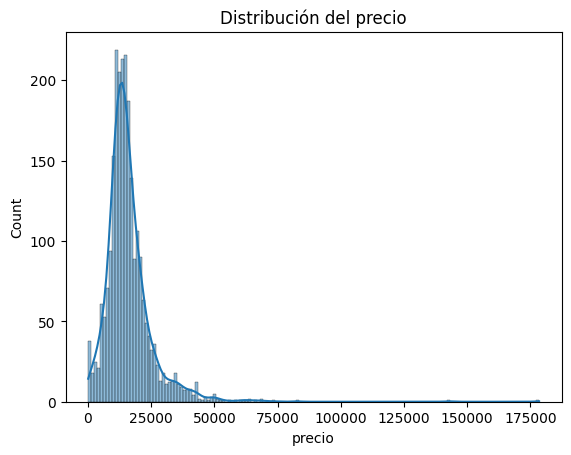

In [21]:
sns.histplot(imdb['precio'], kde=True)
plt.title("Distribución del precio")
plt.show()



Distribucion km

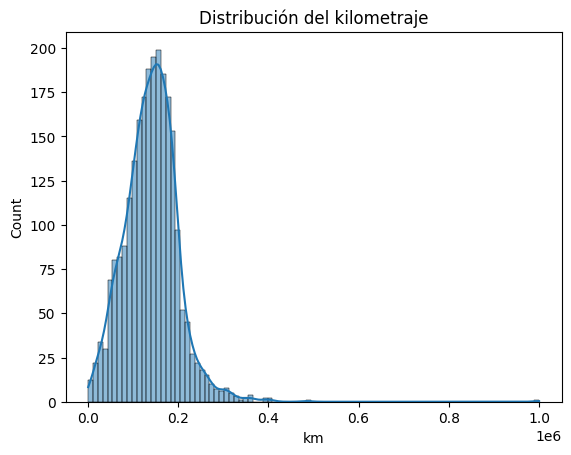

In [22]:
sns.histplot(imdb['km'], kde=True)
plt.title("Distribución del kilometraje")
plt.show()

Distribucion potencia

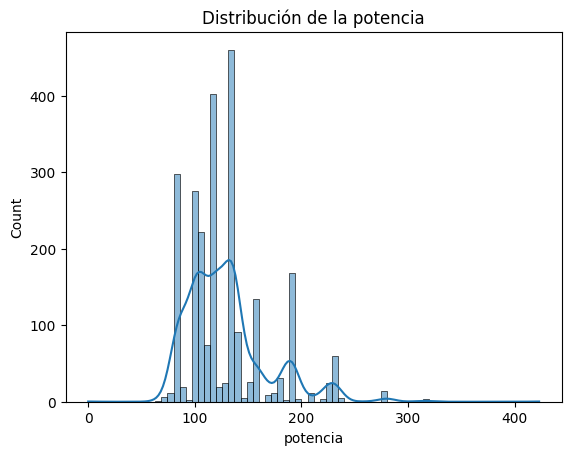

In [23]:
sns.histplot(imdb['potencia'], kde=True)
plt.title("Distribución de la potencia")
plt.show()

4. Matriz de correlación inicial

Limpio las binarias para que no de error

In [25]:
binary_cols = ['volante_regulable', 'aire_acondicionado', 'camara_trasera',
               'elevalunas_electrico', 'bluetooth', 'gps', 'alerta_lim_velocidad']

for col in binary_cols:
    imdb[col] = imdb[col].replace({'Sí':1, 'No':0, 'si':1, 'no':0, 'YES':1, 'NO':0, True:1, False:0})
    imdb[col] = imdb[col].astype(float)


/tmp/ipython-input-1209841506.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  imdb[col] = imdb[col].replace({'Sí':1, 'No':0, 'si':1, 'no':0, 'YES':1, 'NO':0, True:1, False:0})
/tmp/ipython-input-1209841506.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  imdb[col] = imdb[col].replace({'Sí':1, 'No':0, 'si':1, 'no':0, 'YES':1, 'NO':0, True:1, False:0})
/tmp/ipython-input-1209841506.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicit

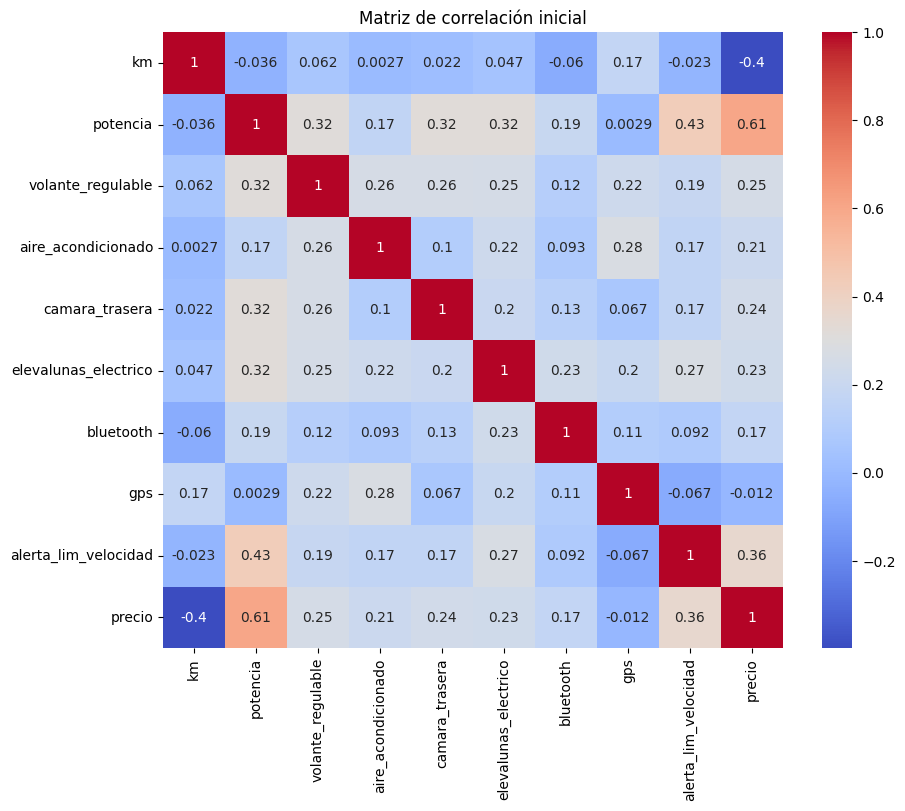

In [26]:
corr = imdb[['km','potencia','volante_regulable','aire_acondicionado',
             'camara_trasera','elevalunas_electrico','bluetooth','gps',
             'alerta_lim_velocidad','precio']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación inicial")
plt.show()

5. Variable vs target

In [ ]:
km vs precio

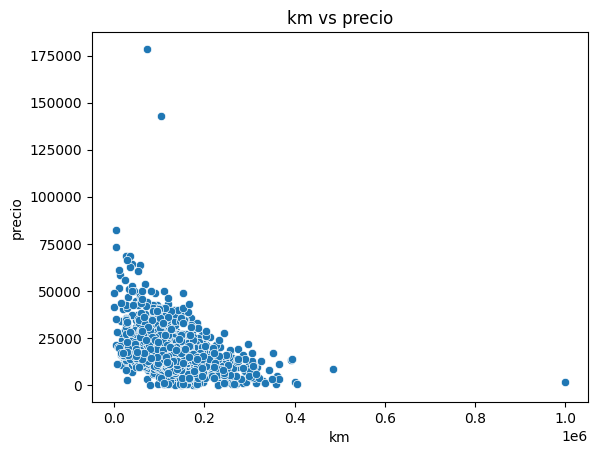

In [27]:
sns.scatterplot(data=imdb, x='km', y='precio')
plt.title("km vs precio")
plt.show()


potencia vs precio

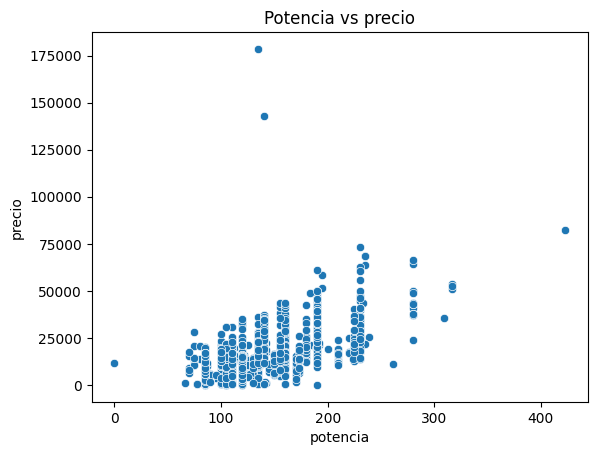

In [28]:
sns.scatterplot(data=imdb, x='potencia', y='precio')
plt.title("Potencia vs precio")
plt.show()


6. Transformación de categóricas

In [29]:
imdb = pd.get_dummies(imdb,
                      columns=['marca', 'modelo', 'tipo_gasolina', 'color', 'tipo_coche'],
                      drop_first=True)

7. Escalado con MinMaxScaler + correlación final

escalada

In [30]:
from sklearn.preprocessing import MinMaxScaler

num_cols = ['km', 'potencia', 'volante_regulable', 'aire_acondicionado',
            'camara_trasera', 'elevalunas_electrico', 'bluetooth', 'gps',
            'alerta_lim_velocidad', 'precio']

scaler = MinMaxScaler()
imdb[num_cols] = scaler.fit_transform(imdb[num_cols])


correlacion

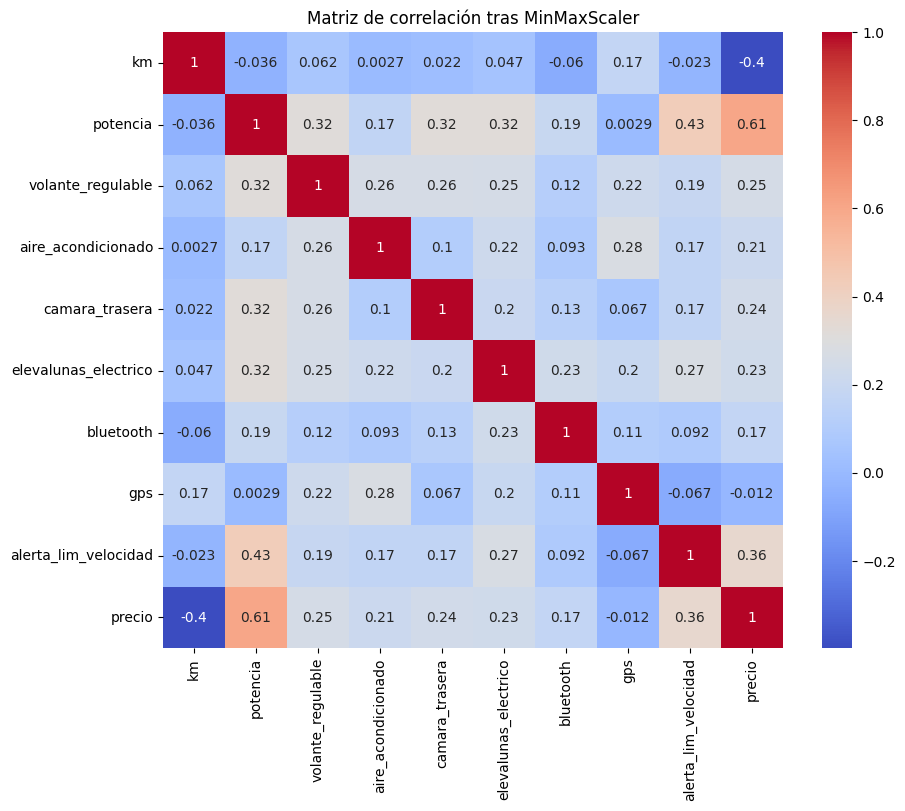

In [31]:
corr_scaled = imdb[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_scaled, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación tras MinMaxScaler")
plt.show()

Dataframe final

In [32]:
imdb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2420 entries, 0 to 4841
Data columns (total 94 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   km                           2419 non-null   float64
 1   potencia                     2419 non-null   float64
 2   fecha_registro               2420 non-null   object 
 3   volante_regulable            2417 non-null   float64
 4   aire_acondicionado           2420 non-null   float64
 5   camara_trasera               2419 non-null   float64
 6   elevalunas_electrico         2419 non-null   float64
 7   bluetooth                    2420 non-null   float64
 8   gps                          2420 non-null   float64
 9   alerta_lim_velocidad         2420 non-null   float64
 10  precio                       2419 non-null   float64
 11  modelo_114                   2420 non-null   bool   
 12  modelo_116                   2420 non-null   bool   
 13  modelo_118             